In [156]:
# Gerekli kütüphaneleri içe aktar
import pandas as pd  # Veri işleme için
import numpy as np   # Sayısal işlemler için
import matplotlib.pyplot as plt  # Grafik çizmek için
import seaborn as sns  # Daha güzel Grafikler için

# Uyarı mesajlarını gizle (ekranı temiz tutmak için)
import warnings
warnings.filterwarnings('ignore')
# Grafiklerin colab içinde görünmesini sağla
%matplotlib inline

In [53]:
# Veriyi csv türünde yükleyeceğiz
df=pd.DataFrame()
import pandas as pd
# Google Colab'a yüklediğiniz dosyayı oku
df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')

In [54]:
# İlk 5 satırı göster
df.head()
#print(df.head())
# Veri şekli yani kaç sütun kaç satır olduğu
#print("\nSatır ve Sütun Sayısı:", df.shape)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [55]:
print("\nSatır ve Sütun Sayısı:" , df.shape)



Satır ve Sütun Sayısı: (541909, 8)


In [56]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [57]:
# customer ıd si olmayanları temizleyeceğiz
df=df[pd.notnull(df['CustomerID'])]
print("eksik customerID ler çıkarıldı")

eksik customerID ler çıkarıldı


In [58]:
# CustomerID leri getir
df['CustomerID'].value_counts()

,count
CustomerID,
17841.0,7983
14911.0,5903
14096.0,5128
12748.0,4642
14606.0,2782
...,...
17986.0,1
13256.0,1
18184.0,1


In [59]:
df.info() # CustomerID si olmayanları çıkardıktan sonra kullanılan belleğin azaldığını görebiliriz


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [60]:
#CustomerID yi integer (tam sayı) yapıcaz
df['CustomerID'] = df['CustomerID'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  int64  
 7   Country      406829 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 27.9+ MB


In [61]:
df.head() # customerID lerin flot düzeni integer oldumu diye kontrol ettik

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [62]:
# İnvoiceDate sütununu tarih olarak değiştireceğiz
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom


In [63]:
# sadece pozitif miktar ve fiyat içeren satırları al
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]



In [64]:
# Her alışverişin toplam tutarı = miktar x Birim fiyatı
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [65]:
# Kaç Benzersiz Müşterimiz Var
BenzersizMusteriSayisi = df['CustomerID'].nunique()
print("Kaç Benzersiz Müşterimiz Var:", BenzersizMusteriSayisi)


Kaç Benzersiz Müşterimiz Var: 4338


In [66]:
# Müşteri Bazında Toplam Harcamayı hesaplayalım
müsteri_harcama=df.groupby('CustomerID')['TotalPrice'].sum()
müsteri_harcama.head()

,TotalPrice
CustomerID,
12346,77183.60
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40


In [67]:
# TotalPrice sütununu integer (tam sayı) formatında yazıcaz
#df['TotalPrice'] = df['TotalPrice'].astype(int)
#df.head()

In [68]:
# en yüksek 5 harcamayı gösterelim
en_cok_harcama = müsteri_harcama.nlargest(10)
en_cok_harcama


,TotalPrice
CustomerID,
14646,280206.02
18102,259657.30
17450,194550.79
16446,168472.50
14911,143825.06
12415,124914.53
14156,117379.63
17511,91062.38
16029,81024.84


In [69]:
# En Çok Satış Yapan Ülkeler
EnÇokSatışYapanÜlke = df.groupby('Country')['Quantity'].sum().nlargest(10)
EnÇokSatışYapanÜlke


,Quantity
Country,
United Kingdom,4256740
Netherlands,200361
EIRE,140275
Germany,119261
France,111471
Australia,83901
Sweden,36083
Switzerland,30082
Spain,27940


In [70]:
# En Çok Harcama yapan ülkeler
EnÇokHarcamaYapanÜlke =df.groupby('Country')['TotalPrice'].sum().nlargest(10)
EnÇokHarcamaYapanÜlke

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


In [71]:
# RFM analizi Yapacagız (yenilik,sıklık,parasal)
EnSonAlımTarihi = df['InvoiceDate'].max() + pd.Timedelta(days=1)
EnSonAlımTarihi

Timestamp('2011-12-10 12:50:00')

In [89]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [90]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda İnvoiceDate : (EnSonAlımTarihi - İnvoiceDate.max()).days,
                                     'InvoiceNo': lambda InvoiceNo: InvoiceNo.nunique(),
                                     'TotalPrice': lambda TotalPrice: TotalPrice.sum()})d

In [91]:
# R M F değerlerini atayacağız
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [95]:
# monetary sıfırdan buyuk olanı alıcaz
rfm = rfm[rfm['Monetary'] > 0]
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346,326,1,77183.60,1,1,5
12347,2,7,4310.00,5,5,5
12348,75,4,1797.24,2,4,4
12349,19,1,1757.55,4,1,4
12350,310,1,334.40,1,1,2


In [97]:
# RMF skorlarını hesaplayacağız 1-5 arası
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346,326,1,77183,1,1,5
12347,2,7,4310,5,5,5
12348,75,4,1797,2,4,4
12349,19,1,1757,4,1,4
12350,310,1,334,1,1,2


In [102]:
# Skorları İnteger a cevirelim
rfm['Recency'] = rfm['Recency'].astype(int)
rfm['Frequency'] = rfm['Frequency'].astype(int)
rfm['Monetary'] = rfm['Monetary'].astype(int)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183,1,1,5,115
12347,2,7,4310,5,5,5,555
12348,75,4,1797,2,4,4,244
12349,19,1,1757,4,1,4,414
12350,310,1,334,1,1,2,112


In [107]:
# Toplam RFM Skorunu bulalım
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183,1,1,5,115
12347,2,7,4310,5,5,5,555
12348,75,4,1797,2,4,4,244
12349,19,1,1757,4,1,4,414
12350,310,1,334,1,1,2,112
12352,36,8,2506,3,5,5,355
12353,204,1,89,1,1,1,111
12354,232,1,1079,1,1,4,114
12355,214,1,459,1,1,2,112


In [112]:
# Segment Fonksiyonu tanımlayalım
def rfm_segment(row):
  R = row['R_Score']
  F = row['F_Score']

  if R >= 4 and F >= 4 :
    return "Şampiyon Müşteri"
  elif R >= 3 and F >= 3 :
    return "Sadık Müşteri"
  elif R >= 4 and F <= 2 :
    return "Yeni Müşteri"
  elif R <= 2 and F >= 4 :
    return "Kaybedilmekte olan Müşteri"
  elif R <= 2 and F <= 2 :
    return "Kaybedilen Müşteri"
  else :
    return "Uyku Halindeki Müşteri"

# Her satırda bu fonksiyonu uygulayacağız
rfm['Segment']=rfm.apply(rfm_segment,axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,326,1,77183,1,1,5,115,Kaybedilen Müşteri
12347,2,7,4310,5,5,5,555,Şampiyon Müşteri
12348,75,4,1797,2,4,4,244,Kaybedilmekte olan Müşteri
12349,19,1,1757,4,1,4,414,Yeni Müşteri
12350,310,1,334,1,1,2,112,Kaybedilen Müşteri


In [116]:
print(rfm['Segment'].value_counts())
rfm['Segment'].head(10)

Segment
Şampiyon Müşteri              1139
Kaybedilen Müşteri            1065
Sadık Müşteri                  821
Uyku Halindeki Müşteri         719
Yeni Müşteri                   319
Kaybedilmekte olan Müşteri     275
Name: count, dtype: int64


,Segment
CustomerID,
12346,Kaybedilen Müşteri
12347,Şampiyon Müşteri
12348,Kaybedilmekte olan Müşteri
12349,Yeni Müşteri
12350,Kaybedilen Müşteri
12352,Sadık Müşteri
12353,Kaybedilen Müşteri
12354,Kaybedilen Müşteri
12355,Kaybedilen Müşteri


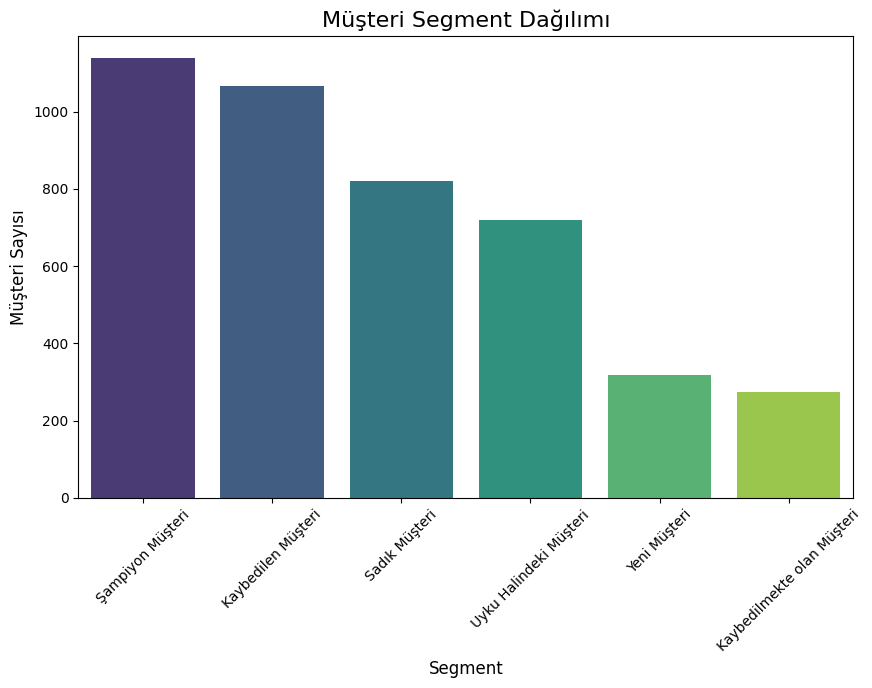

In [113]:
# Çubuk Grafikte Segment Dağılımını göösterelim
plt.figure(figsize=(10,6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Müşteri Segment Dağılımı', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Müşteri Sayısı', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [117]:
# Segment Bazında Ortalama Harcamayı bulalım
segment_ortalama_harcama = rfm.groupby('Segment')['Monetary'].mean()
segment_ortalama_harcama

,Monetary
Segment,
Kaybedilen Müşteri,487.235681
Kaybedilmekte olan Müşteri,1574.916364
Sadık Müşteri,1650.853837
Uyku Halindeki Müşteri,735.426982
Yeni Müşteri,457.733542
Şampiyon Müşteri,5203.823529


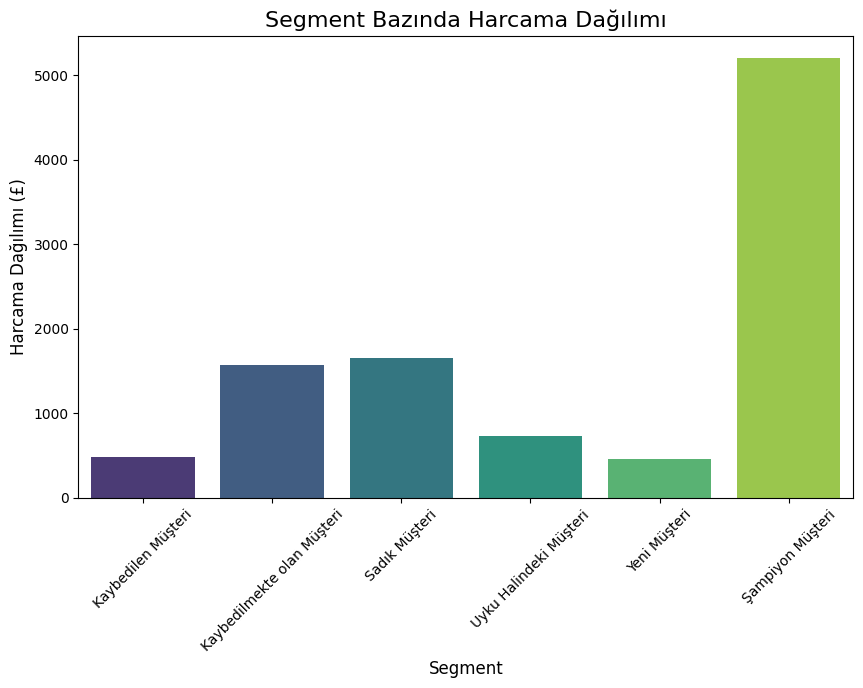

In [124]:
# Şimdi Bunu Grafiğe Dökelim
#plt.figure(figsize=(10,6))
#sns.boxplot(data = rfm , x = 'Segment', y = 'Monetary', order = segment_counts.index)
#plt.title('Segment Bazında Harcama Dağılımı', fontsize=16)
#plt.xticks(rotation=45)
#plt.xlabel('Segment', fontsize=12)
#plt.ylabel('Toplam Harcama (£)')
#plt.show()
#Başka Bir Grafik Deneyelim
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_ortalama_harcama.index, y=segment_ortalama_harcama.values, palette='viridis')
plt.title('Segment Bazında Harcama Dağılımı', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Harcama Dağılımı (£)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


In [128]:
#En Değerli Segmenti İnceleyelim (Şampiyon Müşteriler)
sampionlar = rfm[rfm['Segment'] == 'Şampiyon Müşteri']
print("Şampiyon Müşteri Sayısı:" ,  len(sampionlar))
print("ortalama_harcamaları : ", sampionlar['Monetary'].mean())




Şampiyon Müşteri Sayısı: 1139
ortalama_harcamaları :  5203.823529411765


In [130]:
# Şimdi Öğrendiklerimizi MAKİNE ÖĞRENMESİNE entegre edicez ve verimiz daha güvenilir ve kapsamlı olucak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# RMF stünlarımızı Seçelim
rfm_ml=rfm[['Recency','Frequency','Monetary']]
# ölçeklendirmede StandartScaler  kullanıyoruz
scaler = StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_ml)


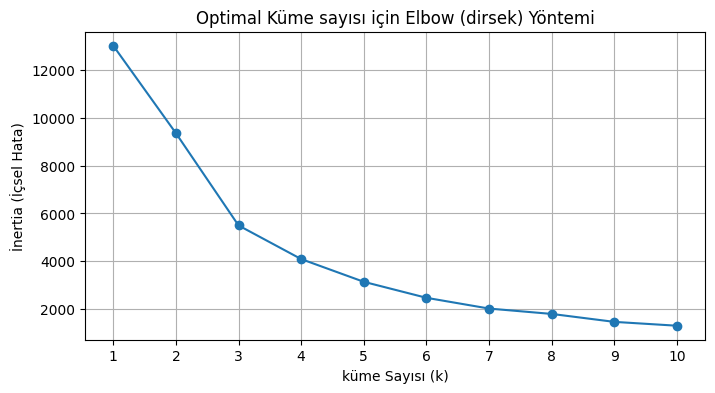

In [144]:
#Şimdi KMeans algoritmasına kaç küme oluşturması gerektiğini söylemeden önce, en uygun küme sayısını (k) bulmamız gerekiyor.
# Dirsek yönetemi kullanıcaz amacımız en uygun k noktasını bulmak
inertia = [] # hata değerlerini tutacağımız listemiz
k_range = range(1,11) # 1 den 10 a kadar k değerlerini deneyeceğiz

for k in k_range :
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

# Grafiği Çizdirelim (Döngü dışında)
plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('küme Sayısı (k)')
plt.ylabel('İnertia (İçsel Hata)')
plt.title('Optimal Küme sayısı için Elbow (dirsek) Yöntemi')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [145]:
# Kırılmamız 3 te gerçekleştiği iççin k = 3 alacağız
# 3 kümeli model yapacağız
kmeans=KMeans(n_clusters=3,random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [147]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
CustomerID,,,,,,,,,
12346,326,1,77183,1,1,5,115,Kaybedilen Müşteri,1
12347,2,7,4310,5,5,5,555,Şampiyon Müşteri,0
12348,75,4,1797,2,4,4,244,Kaybedilmekte olan Müşteri,0
12349,19,1,1757,4,1,4,414,Yeni Müşteri,0
12350,310,1,334,1,1,2,112,Kaybedilen Müşteri,1


In [148]:
rfm.groupby('Cluster').agg({'Recency':'mean',
                              'Frequency':'mean',
                              'Monetary':['mean' , 'count']}).round(2)


Recency Frequency   Monetary      
           mean      mean       mean count
Cluster                                   
0         40.98      4.85    2011.62  3231
1        246.02      1.58     630.67  1093
2          7.14     80.21  122887.86    14

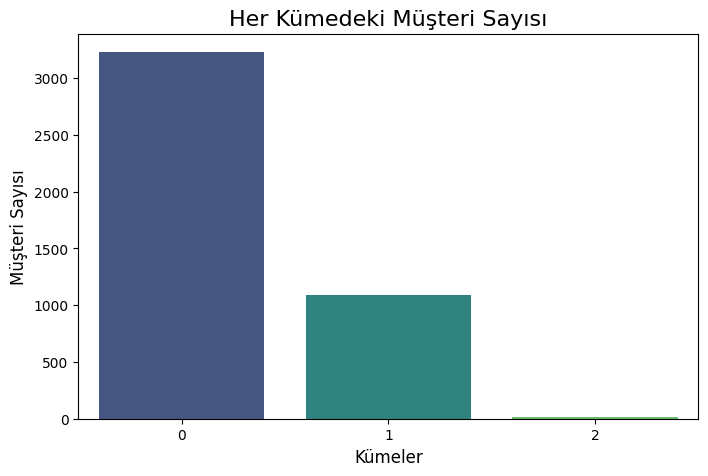

In [152]:
# Barplot Küme  Dağılımını gösterelim
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Cluster', palette='viridis')
plt.title('Her Kümedeki Müşteri Sayısı', fontsize=16)
plt.xlabel('Kümeler', fontsize=12)
plt.ylabel('Müşteri Sayısı', fontsize=12)
plt.show()

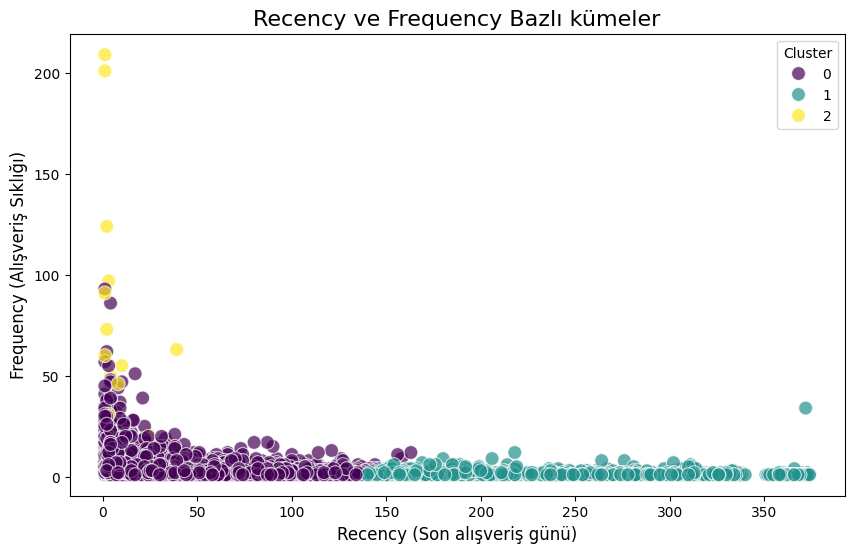

In [159]:
# Şimdi Veriyi daha iyi anlamak için scatterplot kullanalım
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='viridis' , s=100 , alpha= 0.7)
plt.title('Recency ve Frequency Bazlı kümeler', fontsize=16)
plt.xlabel('Recency (Son alışveriş günü)', fontsize=12)
plt.ylabel('Frequency (Alışveriş Sıklığı)', fontsize=12)
plt.legend(title ='Cluster')
plt.show()

*Şimdi Yaptığımız Müşteri Davranışı Analizi Projesi Sonucunda Müşterilere Karşı nasıl Yaklaşmamız gerektiğini anlatayım*
1. **Cluster 2 — VIP / Süper Sadık Müşteriler**

`Özellikler:`
Çok sık alışveriş yapıyorlar.
Yüksek harcama yapıyorlar.
Son alışverişleri çok yakın.

`Stratejiler:`

Özel sadakat programları: VIP üyelikler, erken erişim, özel indirimler.

Kişiselleştirilmiş teklifler: İlgi alanlarına göre kişiye özel kampanyalar.

Ödüllendirme: Puan sistemi, ücretsiz kargo, hediyeler.

Özel hizmet: VIP müşteri destek hattı, danışmanlık.

`Ödüllendirme:`

Puan sistemi, ücretsiz kargo, hediyeler.

Özel hizmet: VIP müşteri destek hattı, danışmanlık.

---
2. **Cluster 0 — Aktif-Orta Seviye Müşteriler**

`Özellikler:`
Orta sıklıkta alışveriş yapıyorlar.
Ortalama harcama düzeyi.
Müşteri sayısı en fazla.

`Stratejiler:`
Sadakat programları: Puan toplama, indirim kuponları.
Çapraz satış ve upsell: Benzer ürün önerileri, paket fırsatları.
Eğitim ve bilgilendirme: Yeni ürün tanıtımları, faydalı içerikler.
Düzenli iletişim: E-posta bültenleri, kampanya bildirimleri.

---
3. **Cluster 1 — Pasif / Kaybedilmiş Müşteriler**

`Özellikler:`

Uzun süredir alışveriş yapmıyorlar.

Düşük alışveriş sıklığı ve harcama.

`Stratejiler:`

Geri kazanım kampanyaları: Özel indirimler, kişiye özel kuponlar.

Hatırlatma ve teşvik: E-posta veya SMS ile hatırlatma mesajları.

Anket ve geri bildirim: Neden alışveriş yapmadıklarını anlamak için sorular.

Kısıtlı süreli teklifler: Aciliyet yaratan fırsatlar.
